# Multi-Model Trading Analysis — Summary

Walk-forward out-of-sample comparison of MLR, ARIMA, GARCH, mean reversion (OU/AR1), and XGBoost on SPY & QQQ.

**Run all models:**
```bash
python modeling/run_all.py
```

Or individually: `python modeling/run_mlr.py`, `run_arima.py`, `run_garch.py`, `run_mean_reversion.py`, `run_gbm.py`

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RESULTS_DIR = Path("results")
sns.set_theme(style="whitegrid")

def load_json(name):
    path = RESULTS_DIR / f"{name}.json"
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run: python modeling/run_all.py")
    with open(path) as f:
        return json.load(f)

combined_path = RESULTS_DIR / "combined_summary.json"
if combined_path.exists():
    with open(combined_path) as f:
        combined = json.load(f)
    df = pd.DataFrame(combined["comparison_table"])
else:
    rows = []
    for model in ("mlr", "arima", "garch", "mean_reversion", "gbm"):
        p = load_json(model)
        for run in p["runs"]:
            if model == "garch":
                for variant in ("garch", "rolling_20d"):
                    wf = run[variant]["walk_forward"]
                    rows.append({"model": f"garch_{variant}", "symbol": run["symbol"],
                                 "target": run["target"], **{k: wf.get(k) for k in ("rmse", "oos_r2", "qlike", "accuracy")}})
            else:
                wf = run.get("walk_forward", {})
                rows.append({"model": model, "symbol": run.get("symbol", ""),
                             "target": run.get("target", ""), "series": run.get("series", ""),
                             **{k: wf.get(k) for k in ("rmse", "oos_r2", "qlike", "accuracy")}})
    df = pd.DataFrame(rows)

df.head(10)

,model,symbol,target,series,rmse,oos_r2,qlike,accuracy
0,arima,SPY,next_day_return,,0.009261,-0.305183,NaN,0.520138
1,arima,QQQ,next_day_return,,0.010523,-0.006779,NaN,0.502304
2,garch_garch,SPY,next_day_vol,NaN,0.007926,-28.739010,-9.735214,NaN
3,garch_rolling_20d,SPY,next_day_vol,NaN,0.005994,-16.007247,-10.005390,NaN
4,garch_garch,QQQ,next_day_vol,NaN,0.009311,-29.023649,-9.142408,NaN
5,garch_rolling_20d,QQQ,next_day_vol,NaN,0.007494,-18.448832,-9.369360,NaN
6,gbm,SPY,same_day_rth,,0.008148,-0.018362,NaN,0.537736
7,gbm,SPY,next_day_return,,0.008117,-0.009722,NaN,0.527745
8,gbm,SPY,next_day_vol,,0.001213,0.313433,-11.165291,NaN
9,gbm,QQQ,same_day_rth,,0.010499,-0.016652,NaN,0.525384


## OOS R² by model × target × symbol

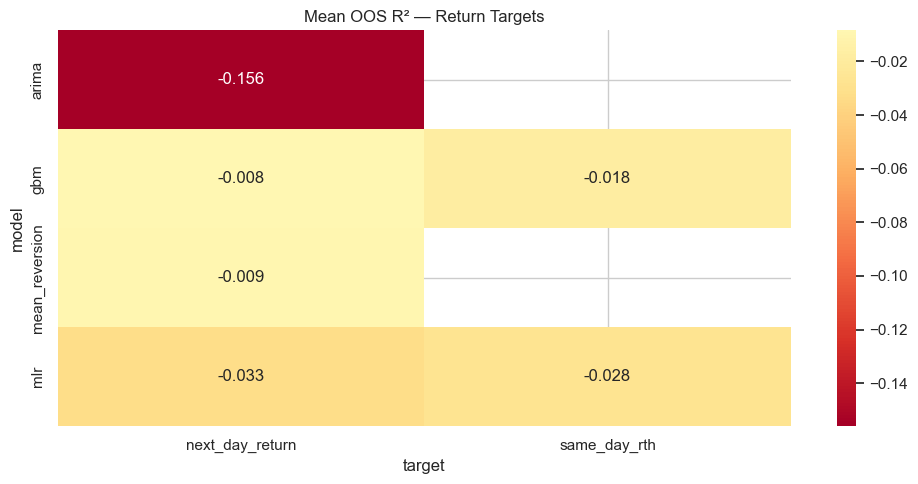

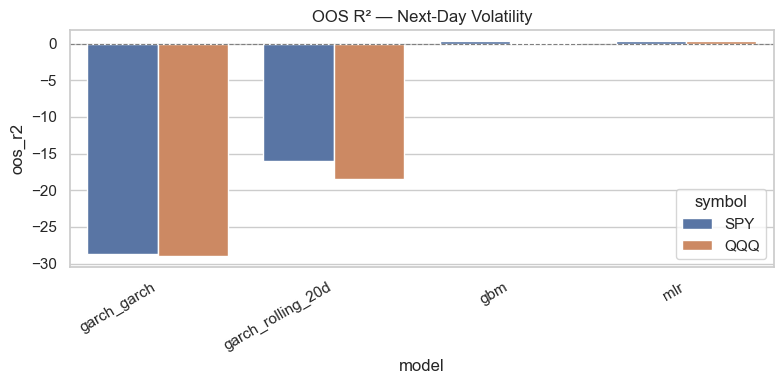

In [2]:
ret_df = df[df["target"].isin(["same_day_rth", "next_day_return"])].copy()

if not ret_df.empty:
    pivot = ret_df.pivot_table(index="model", columns="target", values="oos_r2", aggfunc="mean")
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn", center=0, ax=ax)
    ax.set_title("Mean OOS R² — Return Targets")
    plt.tight_layout()
    plt.show()

vol_df = df[df["target"] == "next_day_vol"].copy()
if not vol_df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(data=vol_df, x="model", y="oos_r2", hue="symbol", ax=ax)
    ax.set_title("OOS R² — Next-Day Volatility")
    ax.axhline(0, color="gray", ls="--", lw=0.8)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

## Volatility: GARCH vs rolling baseline

,symbol,variant,rmse,qlike,oos_r2
0,SPY,"GARCH(1,1)",0.007926,-9.735214,-28.739010
1,SPY,Rolling 20d,0.005994,-10.005390,-16.007247
2,QQQ,"GARCH(1,1)",0.009311,-9.142408,-29.023649
3,QQQ,Rolling 20d,0.007494,-9.369360,-18.448832


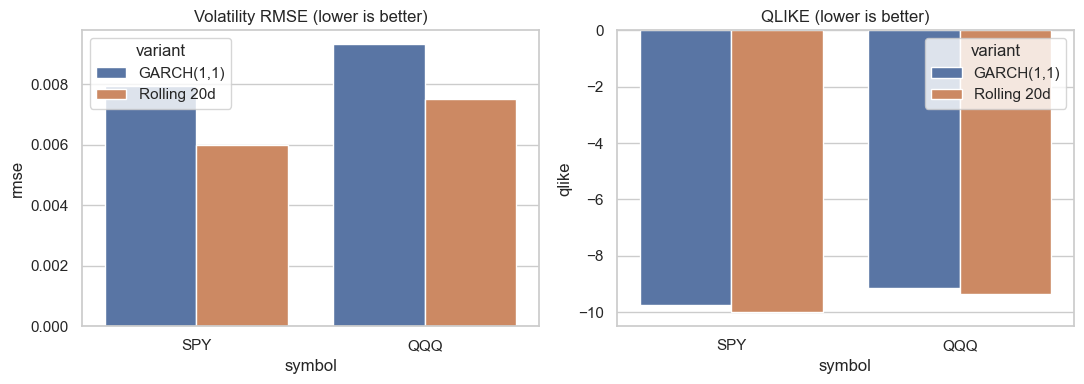

In [3]:
garch = load_json("garch")
vol_rows = []
for run in garch["runs"]:
    for variant, label in (("garch", "GARCH(1,1)"), ("rolling_20d", "Rolling 20d")):
        wf = run[variant]["walk_forward"]
        vol_rows.append({
            "symbol": run["symbol"], "variant": label,
            "rmse": wf["rmse"], "qlike": wf.get("qlike"), "oos_r2": wf.get("oos_r2"),
        })
vol_cmp = pd.DataFrame(vol_rows)
display(vol_cmp)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=vol_cmp, x="symbol", y="rmse", hue="variant", ax=axes[0])
axes[0].set_title("Volatility RMSE (lower is better)")
sns.barplot(data=vol_cmp, x="symbol", y="qlike", hue="variant", ax=axes[1])
axes[1].set_title("QLIKE (lower is better)")
plt.tight_layout()
plt.show()

## Mean reversion: half-life & stationarity

,symbol,series,phi,half_life_days,adf_p,stationary,oos_rmse,direction_acc
0,SPY,rth_return,-0.0970,0.2971,0.0,True,0.0081,0.5466
1,SPY,premarket_return,0.0076,0.1420,0.0,True,0.0060,0.5063
2,QQQ,rth_return,-0.0540,0.2374,0.0,True,0.0105,0.5288
3,QQQ,premarket_return,-0.0361,0.2087,0.0,True,0.0080,0.5098
4,SPY_QQQ,spy_minus_qqq_rth_spread,0.0280,0.1939,0.0,True,0.0039,0.5063


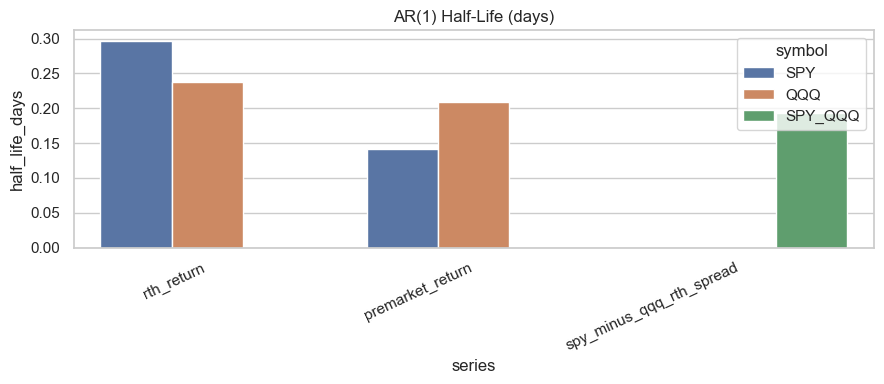

In [4]:
mr = load_json("mean_reversion")
mr_rows = []
for run in mr["runs"]:
    ou = run["ou_params_full_sample"]
    adf = run.get("adf_test", {})
    mr_rows.append({
        "symbol": run["symbol"], "series": run.get("series", ""),
        "phi": ou["phi"], "half_life_days": ou["half_life"],
        "adf_p": adf.get("p_value"), "stationary": adf.get("stationary_5pct"),
        "oos_rmse": run["walk_forward"]["rmse"],
        "direction_acc": run["walk_forward"].get("accuracy"),
    })
mr_df = pd.DataFrame(mr_rows)
display(mr_df.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
plot_df = mr_df[mr_df["half_life_days"].replace([np.inf], np.nan).notna()]
sns.barplot(data=plot_df, x="series", y="half_life_days", hue="symbol", ax=ax)
ax.set_title("AR(1) Half-Life (days)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## GBM feature importance (top features per target)


SPY — same_day_rth


,feature,importance
0,rth_ret_lag_1,0.134436
1,rth_ret_lag_2,0.102189
2,realized_vol_lag_1,0.101491
3,rth_ret_roll_std_5,0.094222
4,pre_vol_ratio,0.091396
5,rth_ret_lag_5,0.086520
6,rth_ret_roll_mean_5,0.073394
7,realized_vol_roll_mean_5,0.065555
8,last30_pre_return,0.061933
9,gap_pct,0.057665


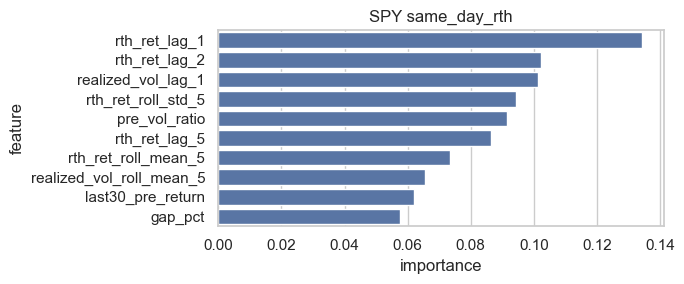


SPY — next_day_return


,feature,importance
0,pre_ret_lag_1,0.128069
1,rth_return,0.090935
2,rth_ret_lag_1,0.089817
3,rth_ret_lag_2,0.080283
4,gap_pct,0.066717
5,rth_ret_roll_std_5,0.064064
6,realized_vol_roll_mean_20,0.059776
7,rth_ret_roll_mean_20,0.053451
8,premarket_return,0.053051
9,realized_vol_roll_mean_5,0.047964


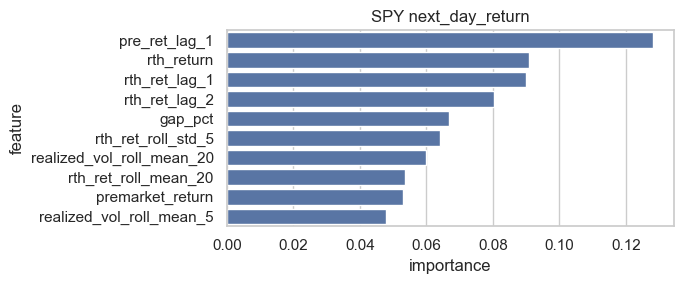


SPY — next_day_vol


,feature,importance
0,realized_vol_roll_mean_5,0.241913
1,rth_ret_roll_std_20,0.126158
2,realized_vol,0.078320
3,realized_vol_lag_1,0.072630
4,rth_ret_roll_std_5,0.068941
5,rth_return,0.055514
6,dow_3,0.052371
7,realized_vol_roll_mean_20,0.049719
8,rth_ret_lag_1,0.048075
9,pre_ret_lag_1,0.047001


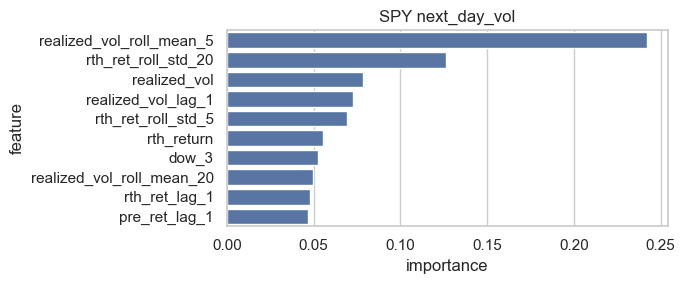


QQQ — same_day_rth


,feature,importance
0,spy_premarket_return_lag_1,0.105866
1,spy_rth_return_lag_1,0.089699
2,realized_vol_lag_1,0.086427
3,rth_ret_lag_2,0.081215
4,rth_ret_roll_std_5,0.064652
5,spy_premarket_return,0.064358
6,rth_ret_lag_5,0.063174
7,rth_ret_roll_mean_5,0.062566
8,gap_pct,0.056434
9,rth_ret_lag_1,0.054973


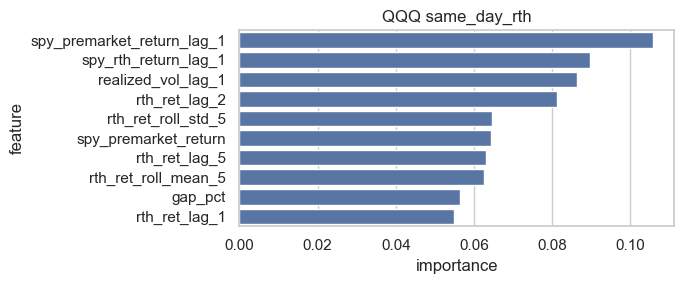


QQQ — next_day_return


,feature,importance
0,last30_pre_return,0.157544
1,spy_rth_return,0.087013
2,premarket_return,0.083932
3,rth_ret_lag_1,0.057740
4,rth_ret_lag_2,0.057364
5,spy_rth_return_lag_1,0.052739
6,realized_vol_roll_mean_5,0.052718
7,spy_premarket_return,0.045056
8,rth_ret_roll_std_5,0.043161
9,rth_ret_roll_mean_5,0.042951


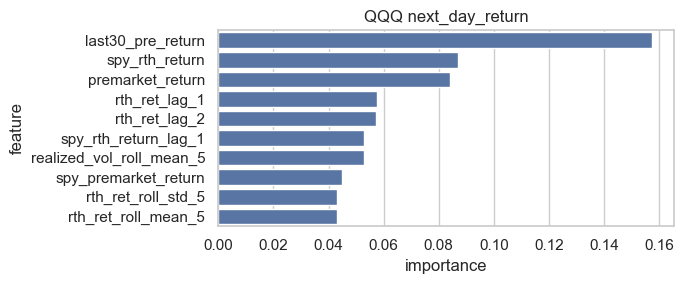


QQQ — next_day_vol


,feature,importance
0,realized_vol_roll_mean_5,0.190058
1,rth_ret_roll_std_20,0.137621
2,rth_ret_roll_std_5,0.061206
3,realized_vol_lag_1,0.060843
4,realized_vol_roll_mean_20,0.058978
5,realized_vol,0.057712
6,spy_realized_vol,0.052866
7,dow_3,0.052016
8,rth_return,0.051523
9,rth_ret_lag_1,0.049024


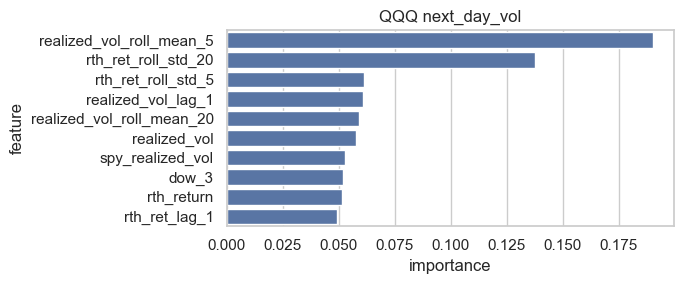

In [5]:
gbm = load_json("gbm")
for run in gbm["runs"]:
    print(f"\n{run['symbol']} — {run['target']}")
    top = pd.DataFrame(run["top_features"])
    display(top)

    fig, ax = plt.subplots(figsize=(7, 3))
    sns.barplot(data=top, y="feature", x="importance", ax=ax)
    ax.set_title(f"{run['symbol']} {run['target']}")
    plt.tight_layout()
    plt.show()

## Interpretation

| Target | Best model (typical) | Notes |
|--------|---------------------|-------|
| Same-day RTH | None clearly wins | OOS R² ≈ 0; PM→RTH signal weak (consistent with `premarket_analysis.ipynb`) |
| Next-day return | GBM ≈ MLR ≈ naive | ARIMA often worse than mean forecast |
| Next-day vol | MLR / rolling std | GARCH competitive; check QLIKE vs RMSE |
| Mean reversion | N/A | Half-life < 1 day → returns look like noise, not OU process |

**Caveat:** Negative OOS R² means the model underperforms predicting the historical mean. This is expected for efficient-market daily returns.